In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct
plt.style.use('mplstyle')

In [214]:
# inputs
nua = np.load('nua.npy')
nc = len(nua)
nuc = nua.mean()/1e6
dnuc = abs(nua[1] - nua[0])/1e6
dnu = np.arange(nc)*dnuc

# redshift params
zz = 1420./nuc -1
r, rp = pfunc.rrprime(zz, 'astropy')
fac = r/(rp*nuc) # theoretically predicted FG wedge boundary: kpara_H = fac*kper
dkl = 0. # fixed buffer

# baseline, ell, kper, kpara
Umin, Umax, Nbin = 6, 220, 20
edges = np.geomspace(Umin, Umax, Nbin + 1)
UU = np.sqrt(edges[:-1] * edges[1:])

ell = 2*np.pi*UU
print('ell:', ell)
nell = len(ell)

kper = ell/r
print('kper:', kper)

# PS params # should be dynamically chosen based on Cl.shape
nc1 = nc # nc - 2*NN can be chosen
vfac = rp*r*r*dnuc*(nc1-1) # DCT factor
kpara = 2.*np.pi*np.arange(nc1)/(rp*(2.*nc1-2.)*dnuc)
print('kpara:', kpara[1], kpara[-1])
w = windows.nuttall(2*nc1)[nc1:] # window for Fourier transform
wf = windows.nuttall(nc1) # window for Fourier transform of visibilities
# kper = kpara.copy()

# # EoR 21-cm PS for Mondal+17
# PK21 = np.load('PK21.npy')
# KK = PK21[:, 0]
# PK = PK21[:, 1]

# EoR power spectrum model in high resolution
KK = np.logspace(np.log10(0.0001), np.log10(10), 1000)
PK = KK**-2



Redshift = 8.206729512407456 
Comoving distance (from astropy): 9209.71452683092 Mpc
rprime (from astropy) = 16.98990953034521 Mpc/MHz
ell: [  41.25132517   49.39141588   59.13778412   70.80739534   84.77976152
  101.50928345  121.54002844  145.52342418  174.23944404  208.62197293
  249.78917851  299.07987554  358.09706604  428.76007112  513.36694997
  614.66923595  735.96142029  881.18809348 1055.0722289  1263.26878045]
kper: [0.00447911 0.00536297 0.00642124 0.00768834 0.00920547 0.01102198
 0.01319694 0.01580108 0.01891909 0.02265238 0.02712236 0.03247439
 0.03888254 0.0465552  0.0557419  0.0667414  0.07991143 0.09568028
 0.1145608  0.13716699]
kpara: 0.0060270313587951685 4.622733052195895


In [215]:
flag = pfunc.flagdata(nc, mode='NOFLAG', percent = 10) # RANDOM, MWA, NOFLAG
flag = pfunc.flagdata(nc, mode='MWA', percent = 50) # RANDOM, MWA, NOFLAG

In [216]:
kp = kper[0]

In [296]:

fact = r**2
ml = pfunc.covtocl_fast(flag, flag) # counter for normalizition 
kv, PKm = pfunc.get_model_pk(kp, kpara, KK, PK)


Nrea = 100  # number of realizations

PKsq_list = []
pk_list = []


nc1 = nc - 0
nc1 = np.argmax(ml.real == 0) if np.any(ml.real == 0) else None

kpara1 = 2.*np.pi*np.arange(nc1)/(rp*(2.*nc1-2.)*dnuc)
w = windows.nuttall(2*nc1)[nc1:] # window for Fourier transform


for i in range(Nrea):    

    # --- get visibilities ---
    VX = pfunc.get_vis(PKm, r, rp, dnuc) * flag
    VY = VX   # or: get_vis(PKm, r, rp, dnuc)*flag

    
    # --- PKsq = |ifft(VX)|^2 ---
    VtauX = dct(VX, type=1) / (2*(2*nc1 - 1)) 
    VtauY = dct(VY, type=1)  / (2*(2*nc1 - 1))
    PKsq =  (VtauY * np.conjugate(VtauX))   +  VtauX * np.conjugate(VtauY) 
    
    # vf = dct(flag, type=1) / (2*(2*nc1 - 1))
    # PKsq_flag =  (vf * np.conjugate(vf))   +  vf * np.conjugate(vf) 
    # sampl_power = np.sum(PKsq_flag.real)
    
    PKsq_list.append(PKsq[:nc1].real*fact)     

    # --- pk from MAPS ---    
    cl = pfunc.covtocl_fast(VY, VX) / ml  
    
    pk  = dct(cl[:nc1] * 1, type=1) / (2*(2*nc1 - 1))
    pk_list.append(pk*fact)


# convert lists to arrays: shape (Nreal, Nk)
PKsq_arr = np.array(PKsq_list)
pk_arr   = np.array(pk_list)


/tmp/ipykernel_5487/1470568054.py:38: RuntimeWarning: invalid value encountered in true_divide
  cl = pfunc.covtocl_fast(VY, VX) / ml


In [297]:
NB = 16
pksq_re = np.zeros((Nrea, NB))
pk_re = np.zeros((Nrea, NB))

kval, PKm = pfunc.get_model_pk(kp, kpara1, KK, PK)

k_cut = np.maximum(kpara[1], kp)
# k_cut = -0.1
idx = np.where(kpara1 > k_cut)[0][0]
print(k_cut, idx)

for ii in range(Nrea):
    pk_re[ii], _, _ = pfunc.bin_array(pk_arr[ii, idx:], NB, kval[idx:], log=False) # False, True
    pksq_re[ii], _, _ = pfunc.bin_array(PKsq_arr[ii, idx:], NB, kval[idx:], log=False)
    
PKM, kk, num = pfunc.bin_array(PKm[idx:], NB, kval[idx:], log=False)  


0.0060270313587951685 1


/home/asif/Desktop/SCF/pkfuncs.py:199: ComplexWarning: Casting complex values to real discards the imaginary part
  ybin[i] = np.mean(array[mask])


In [298]:
num

array([48, 47, 48, 47, 48, 47, 47, 48, 47, 47, 48, 47, 47, 48, 47, 48])

In [299]:
# PKM = Pk_sph
# kk = k_sph

In [300]:
pksqa = np.mean(pksq_re, axis=0)
pksqe = np.std(pksq_re, axis=0)/np.sqrt(Nrea)

pka = np.mean(pk_re, axis=0)
pke = np.std(pk_re, axis=0)/np.sqrt(Nrea)



/tmp/ipykernel_5487/1469718216.py:65: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  plt.tight_layout()


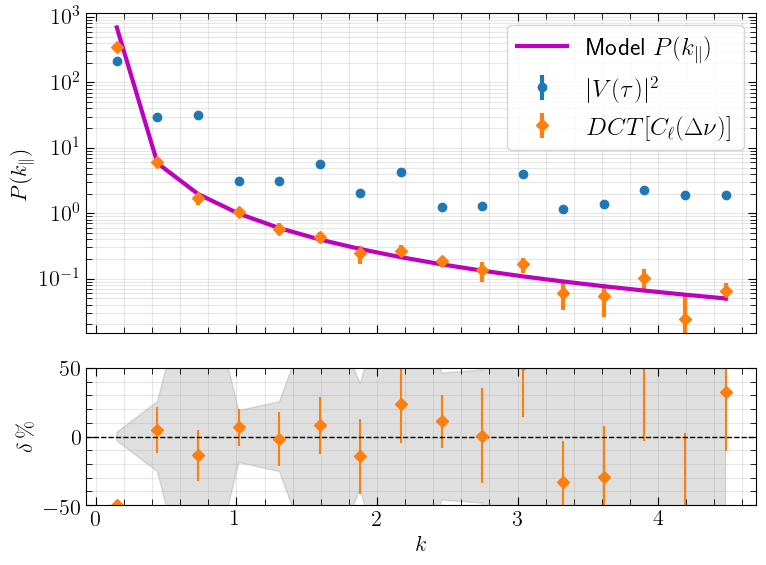

In [305]:
def dev_percent(P, Pm):
    return 100.0 * (P - Pm) / Pm


fig, axs = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.5]}
)

# ---------------------------
# Top panel
# ---------------------------
axs[0].plot(kk, PKM, color='m',
            label=r"Model $P(k_\parallel)$")

# |V(tau)|^2  (delay estimator)
axs[0].errorbar(kk, (pksqa), pksqe, ls='',
                color='C0', errorevery=1,marker='o',
                label=r"$|V(\tau)|^2$")

# Cℓ(Δν) → P(k)
axs[0].errorbar(kk, abs(pka), pke, ls='',
                color='C1', errorevery=1,marker='D',
                label=r"$DCT [ C_\ell(\Delta\nu) ]$")

axs[0].set_ylabel(r"$P(k_\parallel)$ ")
# axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)


# deviation
dev_pk    = dev_percent(pka, PKM)
dev_pksq  = dev_percent(pksqa, PKM)

# deviation std
std_dev_pk   = 100 * pke   / PKM
std_dev_pksq = 100 * pksqe / PKM

err_band = np.maximum(std_dev_pk, std_dev_pksq)

axs[1].fill_between(kk,
                    -err_band, +err_band,
                    color='gray', alpha=0.25, 
                    label=r"$\pm1\sigma$ deviation")

# axs[1].errorbar(kk, dev_pksq, std_dev_pksq, ls='', marker='o',  errorevery=1,
#                 color='C0', label="Delay estimator", lw=1.5)

axs[1].errorbar(kk, dev_pk, std_dev_pk, ls='', marker='D',  errorevery=1,
                color='C1', label="Covariance estimator", lw=1.5)

axs[1].axhline(0, color='k', ls='--', lw=1)
axs[1].set_xlabel(r"$k$")
axs[1].set_ylabel(r"$\delta \,\%$")
axs[1].set_ylim(-50, 50)
# axs[1].legend()
# axs[1].set_xscale('log')
# axs[1].set_yscale('symlog', linthreshy=50)
axs[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


In [306]:
kp

0.0044791100797402965